# 2025-04-17: NDMM BMMC Plasma Cell PAGA Analysis
#### By [Aishwarya Chander](aishwarya.chander@alleninstitute.org), High Resolution Translational Immunology, Allen Institute for Immunology

**Main aim**: PAGA analysis and leiden cluster annotation for PreTx Plasma cells. 

## 1. Imports

In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sc.settings.n_jobs = 30
sc.settings.verbosity = 0

plt.rcParams['figure.dpi'] = 80
plt.rcParams['figure.figsize'] = (5, 5)

sc.settings.set_figure_params(
    dpi=80,
    facecolor='white',
    frameon=False,
    fontsize=10, 
    figsize=(4,4), 
    format='png'
)

## 2. Processed plasma cells at PreTx

In [2]:
adata = sc.read_h5ad('../../../data/rna/plasma-subsets/pretx-plasma-cells.h5ad')
adata.shape

(53946, 32997)

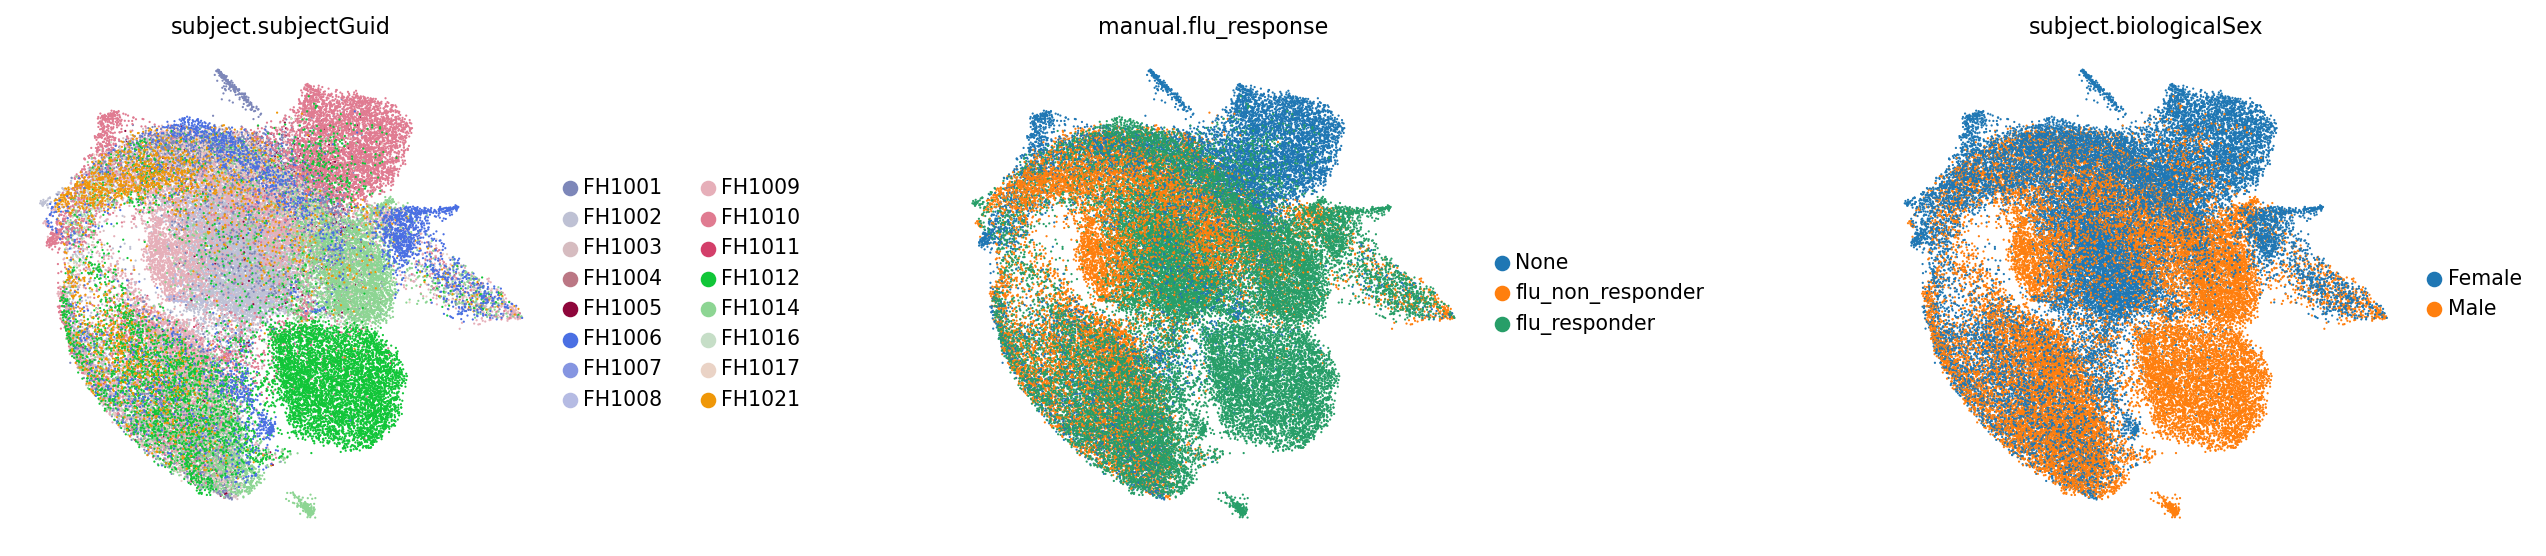

In [3]:
sc.pl.umap(adata, color=['subject.subjectGuid', 'manual.flu_response', 'subject.biologicalSex'], wspace=0.6, size=4)

## 3. PAGA on leiden clusters
> PAGA reveals which clusters are connected, so labels reflect actual transcriptional relationships.

In [4]:
sc.tl.paga(adata, groups='leiden')
sc.pl.paga(adata, plot=False)

In [5]:
sc.tl.draw_graph(adata,
                 init_pos='paga')

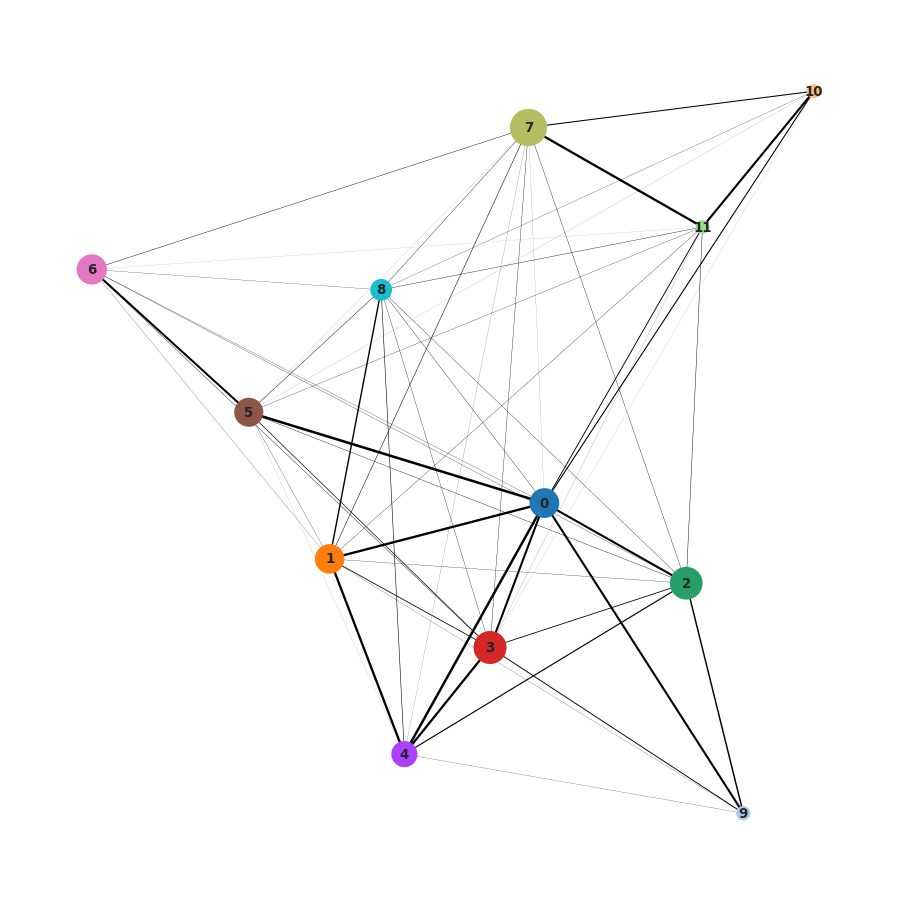

In [6]:
f, axs = plt.subplots(1, 1, figsize=(6, 6))
sns.set(font_scale=1.5)
sns.set_style("white")
axs.axis('off')

sc.pl.paga(adata,
           show=False,
           node_size_scale=1,
           node_size_power=0.5,
           edge_width_scale=0.3,
           ax=axs,
           fontsize=6,
           text_kwds={'alpha': 1})


sns.despine(offset=10, trim=False)
plt.tight_layout()
plt.show(block=False)
plt.close("all")

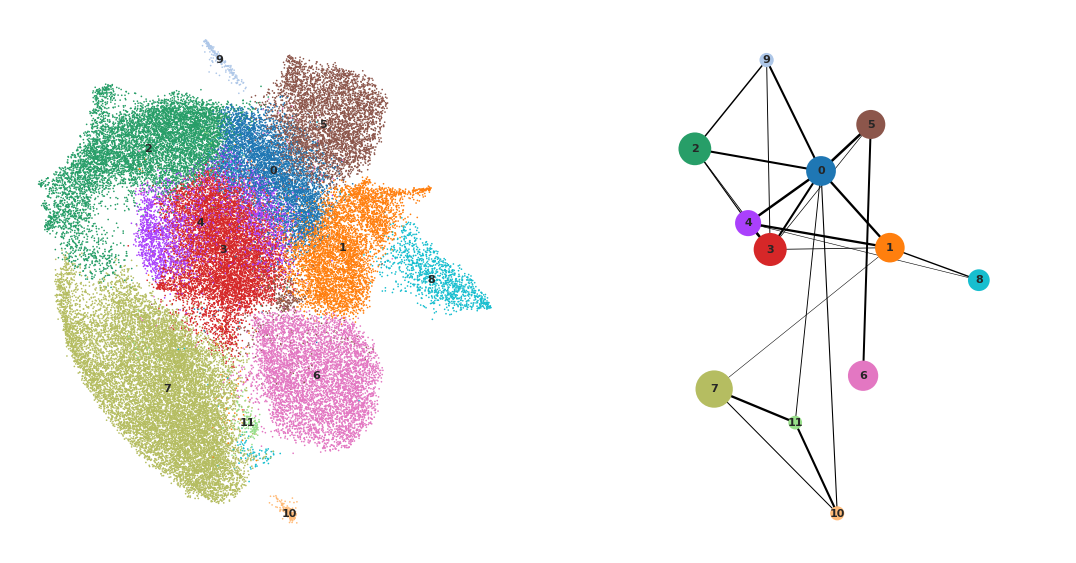

[<Axes: xlabel='UMAP1', ylabel='UMAP2'>, <Axes: >]

In [7]:
sc.pl.paga_compare(adata,
                   threshold=0.1,
                   edge_width_scale=0.3,
                   title='',
                   legend_fontsize=5,
                   frameon=False,
                   edges=False)

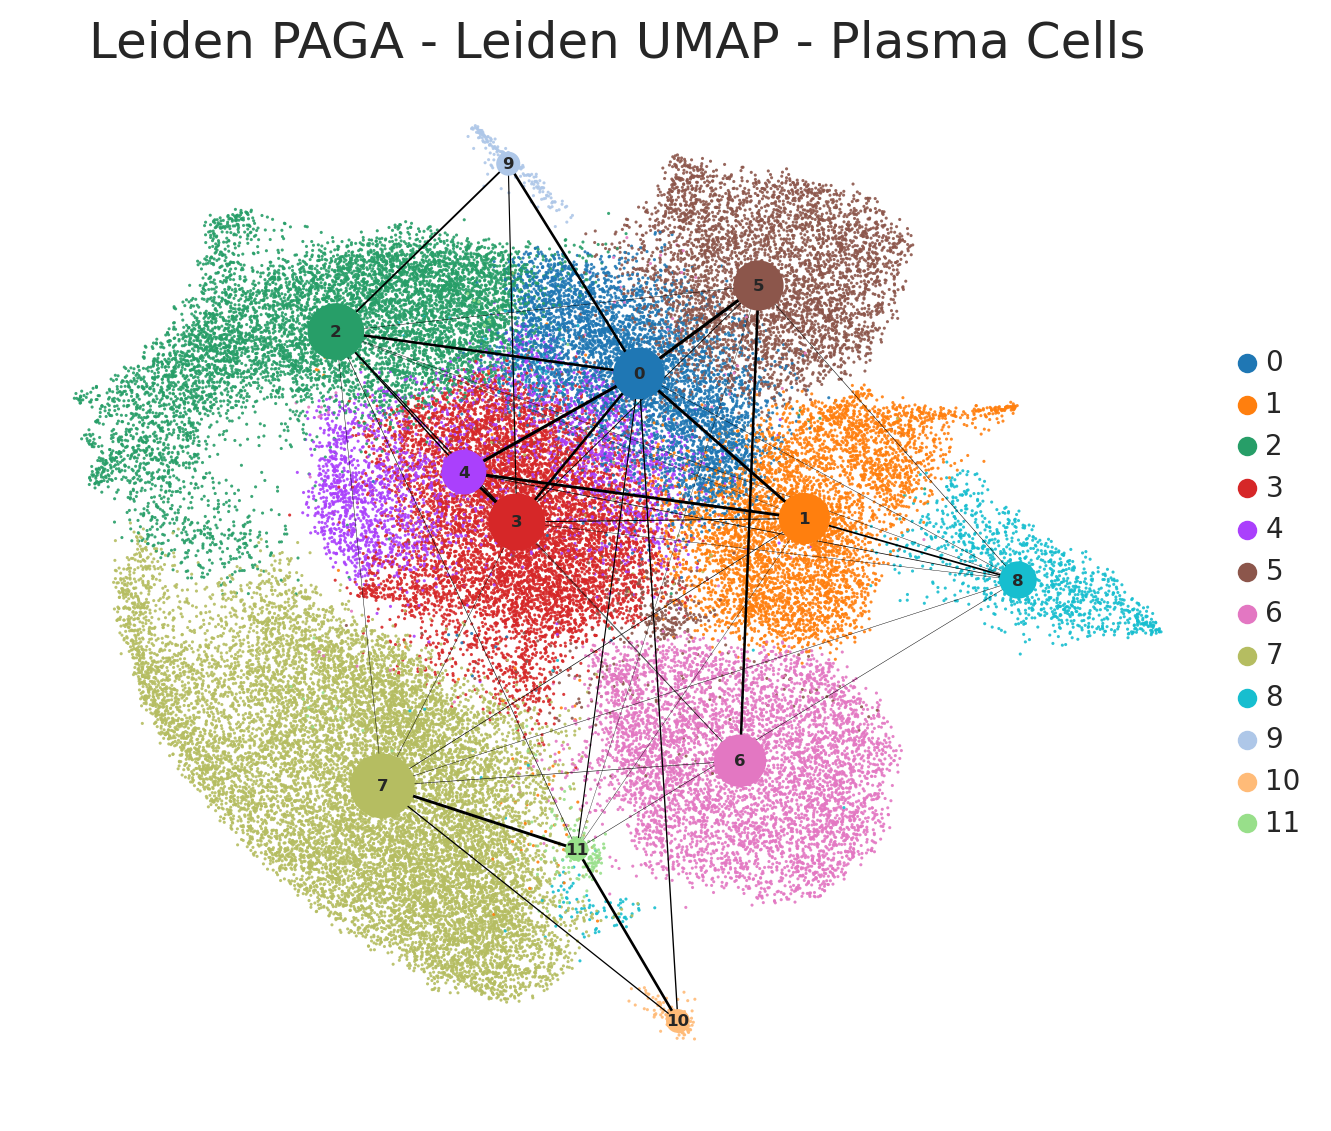

In [8]:
fig, ax = plt.subplots(figsize=(7, 6), dpi=100)
ax.axis('off')

sc.pl.umap(adata, color='leiden', ax=ax, show=False,
           alpha=0.9, size=5, legend_fontsize=10)

sc.pl.paga(adata,
           pos=adata.uns['paga']['pos'],
           show=False,
           threshold=0.05,
           node_size_scale=2,
           edge_width_scale=0.3,
           ax=ax,
           fontsize=6,
           title='Leiden PAGA - Leiden UMAP - Plasma Cells',
           text_kwds={'alpha': 1})

plt.tight_layout()

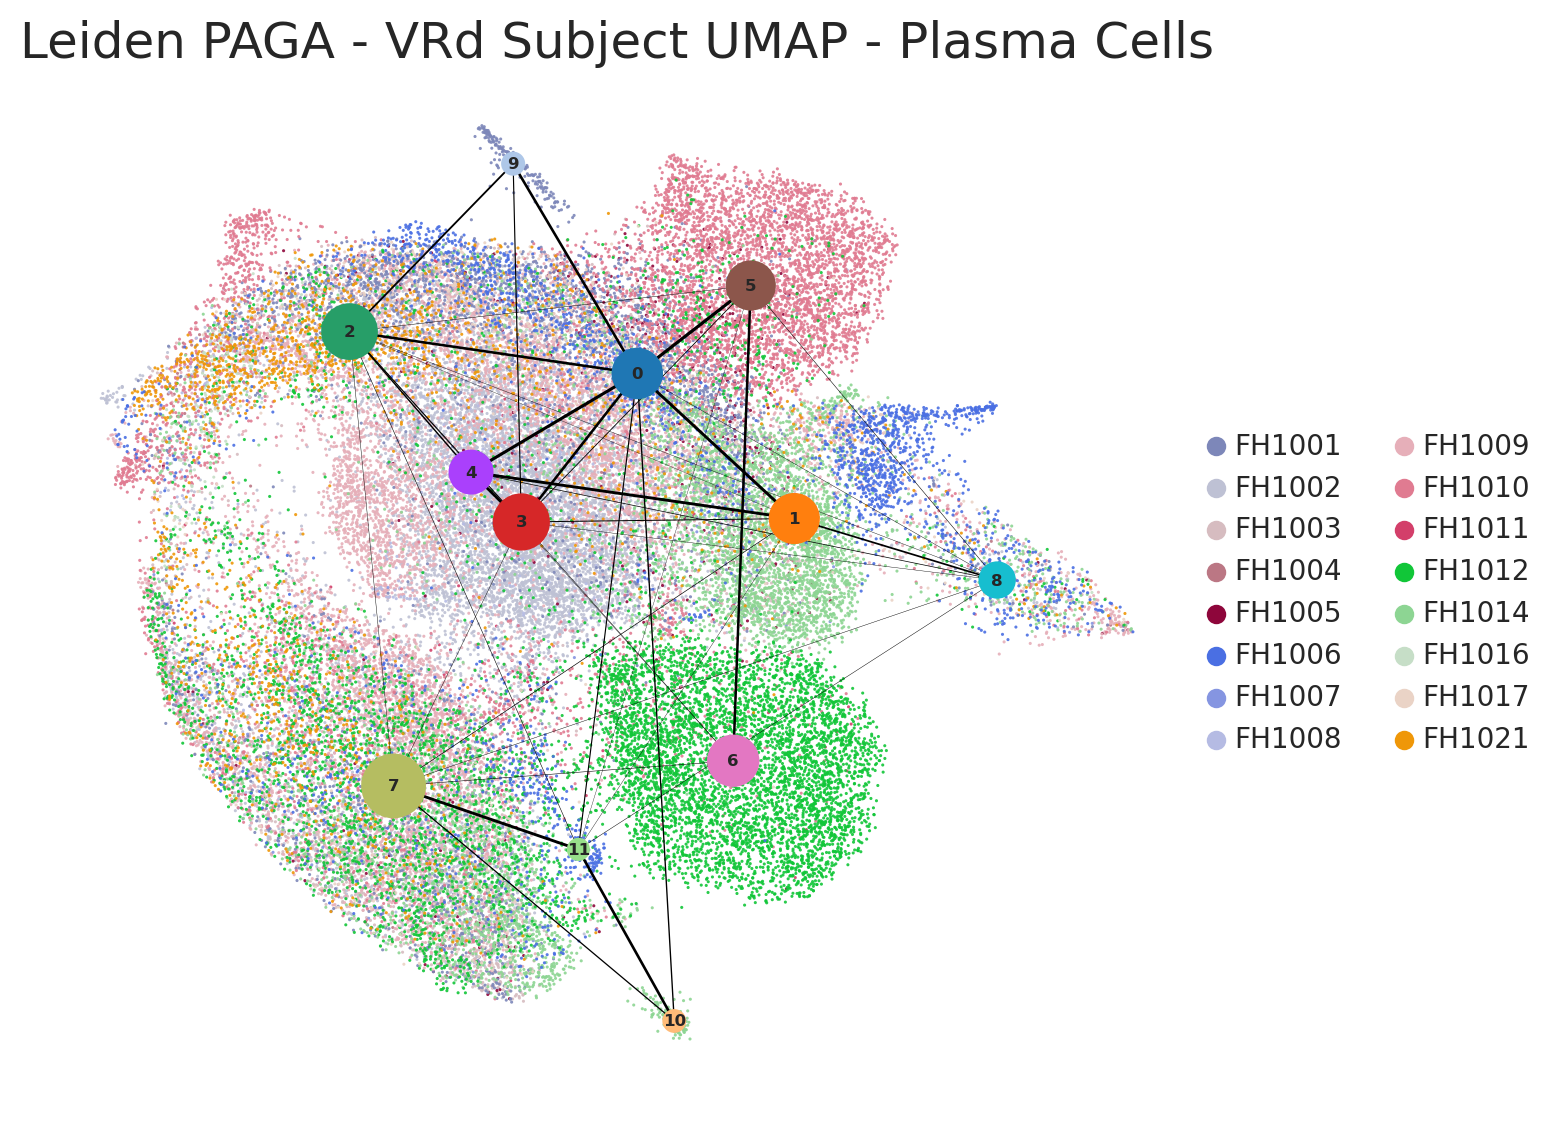

In [9]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
ax.axis('off')

sc.pl.umap(adata, color='subject.subjectGuid', ax=ax,
           show=False, alpha=0.9, size=5, legend_fontsize=10)

sc.pl.paga(adata,
           pos=adata.uns['paga']['pos'],
           show=False,
           threshold=0.05,
           node_size_scale=2,
           edge_width_scale=0.3,
           ax=ax,
           fontsize=6,
           title='Leiden PAGA - VRd Subject UMAP - Plasma Cells',
           text_kwds={'alpha': 1})

plt.tight_layout()

## 4. Cell Cycle Scoring
> Including Cell Cycle Scoring to see how different cell cycle phases impact this. Genes used for scoring are collected from [here](https://www.dropbox.com/s/3dby3bjsaf5arrw/cell_cycle_vignette_files.zip?dl=1).

In [11]:
cell_cycle_genes = [x.strip() for x in open('regev_lab_cell_cycle_genes.txt')]
s_genes = cell_cycle_genes[:43]
g2m_genes = cell_cycle_genes[43:]
cell_cycle_genes = [x for x in cell_cycle_genes if x in adata.var_names]
sc.tl.score_genes_cell_cycle(adata, s_genes=s_genes, g2m_genes=g2m_genes)

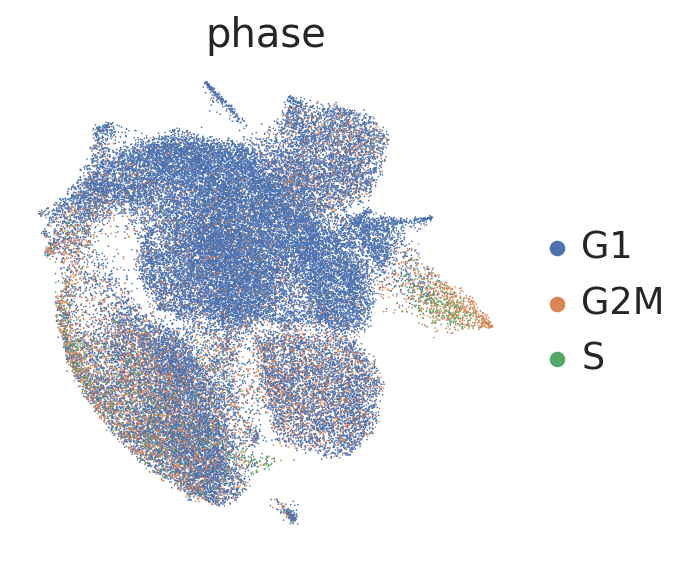

In [15]:
sc.pl.umap(adata, color=['phase'], wspace=0.2)

## 5. Annotation

In [16]:
cluster_dict = {
    "0": "NDMM 0",
    "1": "NDMM 1",
    "2": "NDMM 2",
    "3": "NDMM 3",
    "4": "NDMM 4",
    "5": "NDMM 5",
    "6": "NDMM 6",
    "7": "NDMM 7",
    "8": "NDMM 8",
    "9": "NDMM 9",
    "10": "NDMM 10",
    "11": "NDMM 11"
}

In [17]:
adata.obs['plasma_labels_l3'] = adata.obs['leiden'].map(cluster_dict).fillna(adata.obs['leiden'])

In [23]:
sc.settings.set_figure_params(
    dpi=80,
    facecolor='white',
    frameon=False,
    fontsize=10,
    dpi_save=400,
    figsize=(6,6),
    format='png'
)

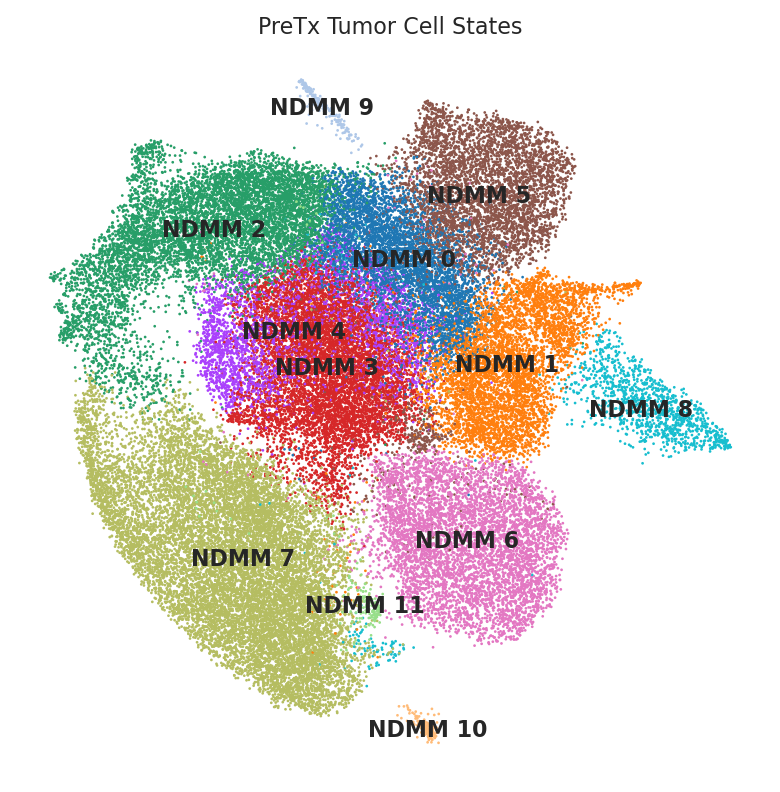

In [24]:
sc.pl.umap(adata, color = 'plasma_labels_l3', size=6, legend_loc='on data', title = 'PreTx Tumor Cell States')

## 6. DEG Analysis

In [25]:
sc.tl.rank_genes_groups(adata, groupby='plasma_labels_l3', method='wilcoxon')

/home/workspace/environment/ndmm-scrna/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:452: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/workspace/environment/ndmm-scrna/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:452: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/workspace/environment/ndmm-scrna/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:453: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/home/workspace/environment/ndmm-scrna/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:452: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/workspace/environment/ndmm-scrna/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:453: RuntimeWarning: overflow encountered in expm1
  self.expm1_func

In [26]:
sc.settings.set_figure_params(
    dpi=200,
    facecolor='white',
    frameon=False,
    fontsize=10,
    dpi_save=400,
    figsize=(6,6),
    format='png'
)

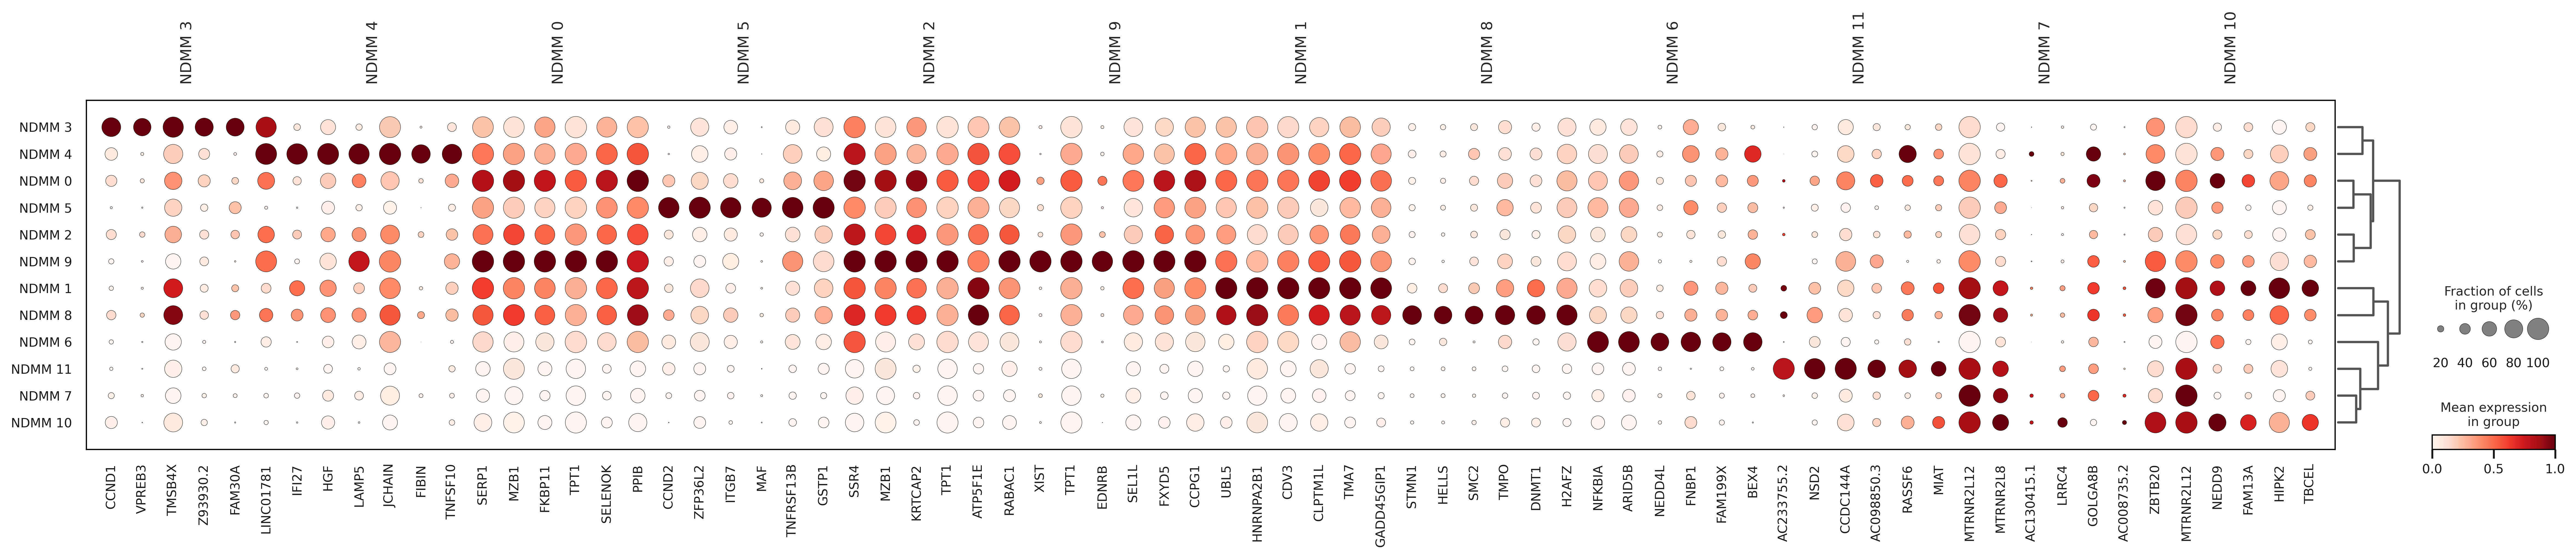

In [27]:
sc.pl.rank_genes_groups_dotplot(adata, groupby='plasma_labels_l3', n_genes=6, standard_scale='var', cmap='Reds')

In [28]:
adata.obs['plasma_annotation_leiden'] = adata.obs['leiden']

## 5. Export data for figures

In [30]:
adata.obs[['plasma_annotation_leiden', 'plasma_labels_l3']].to_parquet('../../../data/rna/bmmc-labels/plasma_pretx_annotation.parquet')
adata.write('../../../data/rna/plasma-subsets/pretx-plasma-paga.h5ad')

## 6. Dataframe for Cytogenetics figure

In [2]:
adata = sc.read_h5ad('../../../data/rna/plasma-subsets/pretx-plasma-paga.h5ad')

In [4]:
adata

AnnData object with n_obs × n_vars = 53946 × 32997
    obs: 'adt_qc_flag', 'adt_umis', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'seurat_pbmc_type', 'seurat_pbmc_type_score', 'umap_1', 'umap_2', 'well_id', 'ext_l1', 'ext_l2', 'ext_l3', 'healthy_l1', 'healthy_l2', 'healthy_l3', 'aifi_l1', 'aifi_l2', 'aifi_l3', 'predicted_doublet', 'doublet_score', 'sample.sampleKitGuid', 'sample.visitDetails', 'sample.visitName', 'sample.drawDate', 'sample.daysSinceFirstVisit', 'sample.diseaseStatesRecordedAtVisit', 'subject.biologicalSex', 'subject.birthYear', 'subject.ethnicity', 'subject.partnerCode', 'subject.race', 'subject.subjectGuid', 'specimen.specimenGuid', 'cohort.cohortGuid', 'manual.time_stamp', 'tissue', 'manual.response', 'manual.response_type', 'manual.extracted_name', 'manual.batch_id', 'manual.category', 'manual.treatment_dara', 'manual.flu_response', '

In [3]:
metadata = pd.read_csv(
    "../../../data/rna/metadata/manually_curated_metadata_gsheet.csv")
add_meta = metadata[metadata["visitDetails"] == "MM Pre-Treatment"][
    [
        "Patient",
        "cyto.17p_loss",
        "cyto.1q_gain",
        "cyto.1p_loss",
        "cyto.high_risk",
        "cyto.karyotype",
        "cyto.t11_14",
        "cyto.t14_16",
        "cyto.t14_20",
        "cyto.t4_14",
    ]
].rename(columns={"Patient": "subject.subjectGuid"})

In [5]:
adata.obs = adata.obs.merge(add_meta, on="subject.subjectGuid", how="left")

/home/workspace/environment/ndmm-scrna/lib/python3.11/site-packages/anndata/_core/anndata.py:750: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    [0, 1, 2, 3, 4]

    Inferred to be: integer

  value_idx = self._prep_dim_index(value.index, attr)


In [6]:
# Genes of interest
genes_of_interest = [
    'CCND1', 'CCND2', 'MAFB', 'TNFSF10', 'RHOA', 'EIF4A2',
    'MAP3K1', 'TERT', 'CSNK1A1', 'CDK6', 'EGFR', 'RAC1',
    'NFKBIA', 'JAK2', 'PTPRD', 'PAK1', 'ATM', 'BIRC3',
    'B2M', 'RAB27A', 'AP3B1', 'AKT2', 'CEBPA', 'ICAM1'
]

# Aggregate, filter genes, and z-score in one flow
patient_mean = adata.to_df().groupby(adata.obs['subject.subjectGuid']).mean()
genes_present = [g for g in genes_of_interest if g in patient_mean.columns]
heatmap_data = patient_mean[genes_present].apply(lambda x: (x - x.mean()) / x.std(), axis=0)

In [7]:
cyto_cols = ['cyto.17p_loss', 'cyto.1q_gain', 'cyto.1p_loss', 'cyto.t11_14', 
             'cyto.t14_16', 'cyto.t14_20', 'cyto.t4_14', 'cyto.karyotype']

cyto_data = (adata.obs[['subject.subjectGuid'] + cyto_cols]
             .drop_duplicates(subset='subject.subjectGuid')
             .set_index('subject.subjectGuid'))

combined_df = heatmap_data.join(cyto_data)
combined_df.to_csv('../../../data/rna/metadata/patient_gex_cyto_for_heatmap.csv')